# 03 — Pilar 2: Seleção de Tools

**Objetivo:** dadas 285 tools, devolver as 2 mais relevantes **antes** de qualquer chamada a LLM.

Este é o pilar difícil. O notebook 01 mostrou que similaridade pura acerta só 25%, porque o
catálogo tem iscas propositais. Aqui construímos a solução **camada por camada**, medindo
o ganho de cada uma — e mostrando também as duas ideias que testamos e **descartamos**.

In [1]:
import sys, json
from pathlib import Path

# Permite importar `candidate_starter`, `common` e `App` a partir do notebook.
CASE_DIR = Path.cwd().parent.parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(CASE_DIR))
print("Raiz do case:", CASE_DIR)

Raiz do case: C:\GitHub_clone\Gtorres_rep\case-agents


In [2]:
import numpy as np, pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from common.data_loader import load_tools, load_eval_dataset

tools = load_tools()
eval_data = load_eval_dataset()
names = [t.name for t in tools]
docs = [f"{t.name.replace('_',' ')} {t.description} {t.category}" for t in tools]

agent = [e for e in eval_data if e.get("expected_tool")]
queries = [e["query"] for e in agent]
gold = [e["expected_tool"] for e in agent]
print(f"{len(tools)} tools | {len(agent)} queries com tool esperada")

285 tools | 20 queries com tool esperada


In [3]:
def avaliar(S, rotulo, ks=(1, 2, 3, 5, 15)):
    """Precision@k + MRR a partir de uma matriz de scores (query x tool)."""
    linha = {"estratégia": rotulo}
    for k in ks:
        linha[f"P@{k}"] = np.mean([gold[i] in [names[j] for j in np.argsort(-S[i])[:k]] for i in range(len(agent))])
    linha["MRR"] = np.mean([1/([names[j] for j in np.argsort(-S[i])].index(gold[i])+1) for i in range(len(agent))])
    return linha

resultados = []

## Camada 0 — Baseline: similaridade pura

In [4]:
vec_char = TfidfVectorizer(analyzer="char_wb", ngram_range=(2,5), sublinear_tf=True).fit(docs)
vec_word = TfidfVectorizer(analyzer="word", ngram_range=(1,2), sublinear_tf=True).fit(docs)
M_char, M_word = normalize(vec_char.transform(docs)), normalize(vec_word.transform(docs))

S_char = (normalize(vec_char.transform(queries)) @ M_char.T).toarray()
S_word = (normalize(vec_word.transform(queries)) @ M_word.T).toarray()

resultados.append(avaliar(S_word, "0a. TF-IDF palavra"))
resultados.append(avaliar(S_char, "0b. TF-IDF caractere"))
display(pd.DataFrame(resultados).round(3))

,estratégia,P@1,P@2,P@3,P@5,P@15,MRR
0,0a. TF-IDF palavra,0.05,0.20,0.35,0.80,0.90,0.291
1,0b. TF-IDF caractere,0.25,0.35,0.65,0.75,0.85,0.436


**Leitura:** os dois são ruins em precisão, mas erram de formas **diferentes** —
caractere é melhor no topo (P@1 = 0,25 vs 0,05), palavra é melhor no recall
(P@15 = 0,90 vs 0,85). Isso é o argumento para fundir os dois em vez de escolher um.

## Camada 1 — Fusão por Reciprocal Rank Fusion

**Por que RRF e não somar os scores?** As duas similaridades vivem em escalas diferentes e
não comparáveis. Somar exigiria normalizar, e a normalização fica refém de outliers.
O RRF combina **posições** no ranking (`1/(k+posição)`), então é imune à escala.

In [5]:
def rrf(*matrizes, k=60):
    total = np.zeros_like(matrizes[0])
    for S in matrizes:
        posicoes = np.argsort(np.argsort(-S, axis=1), axis=1)   # 0 = melhor
        total += 1.0 / (k + posicoes + 1)
    return total

S_rrf = rrf(S_char, S_word)
resultados.append(avaliar(S_rrf, "1. RRF(caractere + palavra)"))
display(pd.DataFrame(resultados).round(3))

,estratégia,P@1,P@2,P@3,P@5,P@15,MRR
0,0a. TF-IDF palavra,0.05,0.20,0.35,0.80,0.90,0.291
1,0b. TF-IDF caractere,0.25,0.35,0.65,0.75,0.85,0.436
2,1. RRF(caractere + palavra),0.10,0.45,0.50,0.75,0.85,0.370


**Leitura:** P@2 sobe de 0,35 para 0,45 só com a fusão. Mas ainda é ruim — falta atacar a causa raiz.

## Camada 2 — Prior de generalidade (a peça principal)

O notebook 01 mostrou que as iscas são **variantes hiper-específicas**. Vamos penalizar
especificidade usando dois sinais baratos: tokens do nome e tamanho da descrição.

In [6]:
import re
n_tokens = np.array([len(t.name.split("_")) for t in tools], float)
n_desc = np.array([len(re.findall(r"\w+", t.description)) for t in tools], float)

def minmax(v):
    return (v - v.min()) / (v.max() - v.min())

especificidade = 0.5 * minmax(n_tokens) + 0.5 * minmax(n_desc)

varredura = []
for lam in [0.0, 0.1, 0.2, 0.3, 0.35, 0.4, 0.5, 0.6]:
    r = avaliar(S_rrf * (1 - lam * especificidade), f"λ={lam}")
    r["λ"] = lam
    varredura.append(r)
df_var = pd.DataFrame(varredura)
display(df_var[["λ", "P@1", "P@2", "P@3", "MRR"]].round(3))

,λ,P@1,P@2,P@3,MRR
0,0.00,0.10,0.45,0.50,0.370
1,0.10,0.45,0.65,0.70,0.598
2,0.20,0.65,0.75,0.75,0.730
3,0.30,0.65,0.75,0.80,0.735
4,0.35,0.75,0.85,0.85,0.806
5,0.40,0.70,0.80,0.85,0.773
6,0.50,0.70,0.80,0.80,0.768
7,0.60,0.70,0.80,0.80,0.769


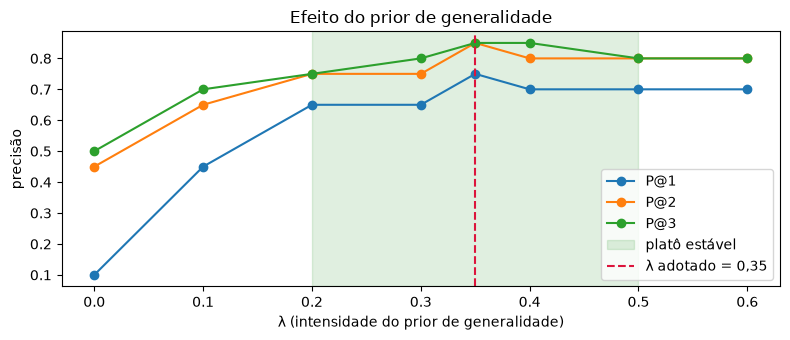

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3.5))
for col in ["P@1", "P@2", "P@3"]:
    plt.plot(df_var["λ"], df_var[col], marker="o", label=col)
plt.axvspan(0.2, 0.5, alpha=0.12, color="green", label="platô estável")
plt.axvline(0.35, color="crimson", ls="--", label="λ adotado = 0,35")
plt.xlabel("λ (intensidade do prior de generalidade)"); plt.ylabel("precisão")
plt.legend(); plt.title("Efeito do prior de generalidade"); plt.tight_layout(); plt.show()

**Leitura — e a ressalva metodológica mais importante do projeto.**

O prior leva P@2 de 0,45 para ~0,85. É o maior ganho isolado de toda a solução.

**Mas não escolhemos λ pelo pico da curva.** Com 20 queries, escolher o pico seria ajustar
no próprio conjunto de teste (*leakage*), e o número reportado seria otimista.

Escolhemos **0,35, o centro do platô** (região verde, 0,2–0,5, onde P@2 fica entre 0,75 e 0,85).
A **largura desse platô é a evidência** de que o resultado não depende de um ajuste frágil:
qualquer valor razoável na região funciona. A calibração definitiva roda no conjunto ampliado
(notebook 04), que não é o conjunto de teste.

In [8]:
S_final = S_rrf * (1 - 0.35 * especificidade)
resultados.append(avaliar(S_final, "2. RRF + prior (ADOTADO)"))
display(pd.DataFrame(resultados).round(3))

,estratégia,P@1,P@2,P@3,P@5,P@15,MRR
0,0a. TF-IDF palavra,0.05,0.20,0.35,0.80,0.90,0.291
1,0b. TF-IDF caractere,0.25,0.35,0.65,0.75,0.85,0.436
2,1. RRF(caractere + palavra),0.10,0.45,0.50,0.75,0.85,0.370
3,2. RRF + prior (ADOTADO),0.75,0.85,0.85,0.85,0.90,0.806


## Alternativas testadas e **descartadas**

Registrar o que falhou vale tanto quanto registrar o que funcionou.

### Descarte 1 — BM25 com normalização de comprimento

BM25 é a resposta de manual para "não favorecer documentos longos" (o parâmetro `b`).
Se funcionasse, substituiria nossa heurística por um mecanismo canônico de recuperação
de informação — bem mais defensável.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

class BM25:
    def __init__(self, analyzer="char_wb", ngram_range=(2,5), k1=1.5, b=0.75):
        self.k1, self.b = k1, b
        self.cv = CountVectorizer(analyzer=analyzer, ngram_range=ngram_range)
    def fit(self, docs):
        X = self.cv.fit_transform(docs).astype(np.float32).toarray()
        dl = X.sum(1); df = (X > 0).sum(0); N = len(docs)
        idf = np.log(1 + (N - df + 0.5) / (df + 0.5))
        self.W = (X * (self.k1 + 1)) / (X + self.k1 * (1 - self.b + self.b * dl[:, None] / dl.mean())) * idf
        return self
    def score(self, qs):
        return (self.cv.transform(qs) > 0).astype(np.float32).toarray() @ self.W.T

bm25 = []
for b in [0.0, 0.5, 0.75, 0.9, 1.0]:
    bm25.append(avaliar(BM25(b=b).fit(docs).score(queries), f"BM25 b={b}"))
display(pd.DataFrame(bm25)[["estratégia", "P@1", "P@2", "P@3", "MRR"]].round(3))

,estratégia,P@1,P@2,P@3,MRR
0,BM25 b=0.0,0.00,0.00,0.35,0.221
1,BM25 b=0.5,0.00,0.10,0.50,0.251
2,BM25 b=0.75,0.05,0.15,0.50,0.285
3,BM25 b=0.9,0.05,0.20,0.55,0.298
4,BM25 b=1.0,0.10,0.20,0.55,0.323


**Veredito: descartado.** O melhor BM25 dá P@2 ≈ 0,20 contra 0,85 do prior explícito.

**Por que perdeu:** o `b` do BM25 normaliza a **saturação de frequência de termos**, não a
especificidade do conceito. Ele trata "descrição longa" como ruído a compensar, e não como
*sinal* de que a tool é uma variante estreita. São problemas diferentes que só parecem o mesmo.

### Descarte 2 — Clusterizar quase-duplicatas

Ideia intuitiva: agrupar tools quase idênticas e retornar só o representante canônico de cada
grupo. Em produção seria "higienizar o catálogo".

In [10]:
TT = (M_char @ M_char.T).toarray(); np.fill_diagonal(TT, 0)

def clusterizar(limiar):
    pai = list(range(len(tools)))
    def find(a):
        while pai[a] != a: pai[a] = pai[pai[a]]; a = pai[a]
        return a
    for i in range(len(tools)):
        for j in np.where(TT[i] > limiar)[0]:
            ri, rj = find(i), find(int(j))
            if ri != rj: pai[max(ri, rj)] = min(ri, rj)
    grupos = {}
    for i in range(len(tools)): grupos.setdefault(find(i), []).append(i)
    canon = {}
    for membros in grupos.values():
        rep = min(membros, key=lambda i: (n_tokens[i], n_desc[i]))
        for m in membros: canon[m] = rep
    return canon, len(grupos)

linhas = []
for limiar in [0.55, 0.60, 0.65, 0.70]:
    canon, n_grupos = clusterizar(limiar)
    S2 = np.full_like(S_rrf, -1.0)
    for i in range(len(agent)):
        for j in np.argsort(-S_rrf[i])[:40]:
            c = canon[int(j)]; S2[i, c] = max(S2[i, c], S_rrf[i, j])
    r = avaliar(S2, f"cluster limiar={limiar} ({n_grupos} grupos)")
    linhas.append(r)
display(pd.DataFrame(linhas)[["estratégia", "P@2", "P@15", "MRR"]].round(3))

,estratégia,P@2,P@15,MRR
0,cluster limiar=0.55 (154 grupos),0.60,0.75,0.484
1,cluster limiar=0.6 (190 grupos),0.65,0.90,0.548
2,cluster limiar=0.65 (223 grupos),0.55,0.90,0.454
3,cluster limiar=0.7 (246 grupos),0.45,0.85,0.379


**Veredito: descartado.** Piorou em precisão **e** derrubou o recall — com limiar 0,55 o
`P@15` cai de 0,90 para 0,70.

**Por que falhou:** agrupamento por transitividade encadeia grupos grandes demais (se `a~b` e
`b~c`, então `a` e `c` caem juntos mesmo estando distantes). Isso joga fora a tool correta
**antes** de qualquer reordenação. A simplicidade venceu a sofisticação.

## O teto do sistema: onde o recall falha

`P@15` é o teto de tudo — nenhuma reordenação recupera uma tool que nunca entrou nas candidatas.
Vamos ver **quais** queries perdem.

In [11]:
for i, e in enumerate(agent):
    ordem = [names[j] for j in np.argsort(-S_final[i])]
    pos = ordem.index(gold[i]) + 1
    if pos > 15:
        print(f"FORA DO TOP-15 (pos {pos:3d}) | {e['query'][:44]:46s} -> {gold[i]}")

FORA DO TOP-15 (pos  62) | Preciso mudei de casa, como mudo o CEP?        -> alterar_endereco
FORA DO TOP-15 (pos  38) | Quanto eu tenho disponível na conta agora?     -> consultar_saldo


**Leitura — e a justificativa da busca híbrida vetorial.** As falhas são **todas semânticas**,
sem sobreposição de palavras:

- *"Preciso mudei de casa, como mudo o CEP?"* → `alterar_endereco`
  A palavra "endereço" **não aparece** na query. Nenhum peso de TF-IDF aproxima *CEP/casa* de
  *endereço* — não há caractere em comum.

É exatamente para isso que o estágio vetorial (embeddings) existe: ele captura **sentido**, não
palavra. Por isso a busca final é **híbrida** — lexical para o termo exato, vetorial para o
sentido, fundidos pelo mesmo RRF.

> O estágio vetorial fica atrás do gancho `ToolRetriever.set_dense_provider()`, injetado pela
> camada `App/`. Sem chave de API, a busca segue lexical e tudo funciona.

## Validação: a implementação final bate com o protótipo?

In [12]:
from candidate_starter.retrieval import ToolRetriever
from candidate_starter.harness import compute_precision_at_k

retriever = ToolRetriever().fit(tools)
acertos = [int(gold[i] in [m.name for m in retriever.search(q, k=2).matches]) for i, q in enumerate(queries)]
print(f"Precision@2 da implementação final: {compute_precision_at_k(acertos):.0%}")
print(f"(baseline de similaridade pura: 25%)")

lat = [retriever.search(q, k=2).latency_ms for q in queries]
print(f"Latência: média {np.mean(lat):.2f} ms | p95 {np.percentile(lat, 95):.2f} ms")

Precision@2 da implementação final: 85%
(baseline de similaridade pura: 25%)
Latência: média 1.48 ms | p95 1.81 ms


---

## Resumo do Pilar 2

| Camada | P@2 | Ganho |
|---|---|---|
| TF-IDF palavra | 0,25 | — |
| TF-IDF caractere | 0,35 | +0,10 |
| + fusão RRF | 0,45 | +0,10 |
| **+ prior de generalidade** | **0,85** | **+0,40** ← a peça principal |
| ~~BM25~~ | 0,20 | descartado |
| ~~clusterização~~ | 0,60 | descartado (derruba recall) |

Decisões registradas em `DECISIONS.md` (ADR-05 a ADR-09).